In [74]:
import pandas as pd
import numpy as np
import gspread

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from google.oauth2.service_account import Credentials

In [ ]:
'''
# Read data from gsheet

SERVICE_ACCOUNT_FILE = '../../key/credentials.json'
SCOPES = ['https://www.googleapis.com/auth/spreadsheets',
          'https://www.googleapis.com/auth/drive']

creds = Credentials.from_service_account_file(SERVICE_ACCOUNT_FILE, scopes=SCOPES)
client = gspread.authorize(creds)

sheet = client.open('[4] AI QC Inbound CRM Review 语音智能质检打标复审').worksheet('New 5')
data = sheet.get_all_records()

df = pd.DataFrame(data[0:], columns=data[0])
df.to_csv('../../raw_data/new_hotline_4.csv', index=False)
'''

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16491 entries, 0 to 16490
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   No                                16491 non-null  int64 
 1   Tanggal Pengerjaan                16491 non-null  object
 2   Checker                           16491 non-null  object
 3   ASI/AFI                           16491 non-null  object
 4   Waktu Inbound                     16491 non-null  object
 5   Nomor Inbound                     16491 non-null  object
 6   Nama Agent                        16491 non-null  object
 7   Call ID                           16491 non-null  object
 8   Durasi Bicara                     16491 non-null  object
 9   Detik                             16491 non-null  object
 10  Total Tiket Riskan                16491 non-null  object
 11  Apakah Riskan?                    16491 non-null  object
 12  Tinjauan CS       

In [8]:
# Lowering all data and removing extra spaces
df_clean = (
    df.copy()
    .drop(columns=['No'])
    .apply(lambda x: x.str.lower() if x.dtype == 'object' else x)
    .apply(lambda x: x.str.strip() if x.dtype == 'object' else x)
)

# lowering all columns names and removing extra spaces
df_clean.columns = (
    df_clean
    .columns.str.lower().str.strip()
    .str.replace(' ', '_')
)

# excluding today date
today = df_clean['tanggal_pengerjaan'].max()
df_clean = df_clean[df_clean['tanggal_pengerjaan'] < today]

# data types
df_clean['tanggal_pengerjaan'] = pd.to_datetime(df_clean['tanggal_pengerjaan'], errors='coerce')

df_clean

,tanggal_pengerjaan,checker,asi/afi,waktu_inbound,nomor_inbound,nama_agent,call_id,durasi_bicara,detik,total_tiket_riskan,...,status,sampling_user_side,hasil_pemeriksaan_kualitas_(old),hasil_asr,hasil_pemeriksaan_kualitas,efektif,kejelasan_suara,suara_lain,kelengkapan_rekaman,agent_sampling
0,2026-03-16,neneng,asi,2026-03-15 20:00:46,0878****0038,isnaini,a84d3724f72046409ec47e2a82cee184,0:07:58,2026-03-15 20:01:32,,...,,done,,,percakapan normal,miss target/ not hc,"sangat jelas, tidak bising sama sekali",0 satu pembicara,0 utuh,
1,2026-03-16,neneng,asi,2026-03-15 20:00:46,0878****0038,isnaini,a84d3724f72046409ec47e2a82cee184,0:07:58,2026-03-15 20:01:40,,...,,done,,,percakapan normal,miss target/ not hc,"sangat jelas, tidak bising sama sekali",0 satu pembicara,0 utuh,
2,2026-03-16,neneng,asi,2026-03-15 20:00:46,0878****0038,isnaini,a84d3724f72046409ec47e2a82cee184,0:07:58,2026-03-15 20:01:47,,...,,done,,,percakapan normal,miss target/ not hc,cukup jelas,0 satu pembicara,0 utuh,
3,2026-03-16,neneng,asi,2026-03-15 20:00:46,0878****0038,isnaini,a84d3724f72046409ec47e2a82cee184,0:07:58,2026-03-15 20:01:50,,...,,done,,,percakapan normal,miss target/ not hc,cukup jelas,0 satu pembicara,0 utuh,
4,2026-03-16,neneng,asi,2026-03-15 20:00:46,0878****0038,isnaini,a84d3724f72046409ec47e2a82cee184,0:07:58,2026-03-15 20:01:52,,...,,done,,,percakapan normal,miss target/ not hc,cukup jelas,0 satu pembicara,0 utuh,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16154,2026-04-14,neneng,asi,2026-04-10 19:27:25,0895*****9445,agus salim prima megah,e5b81d7cccf9406d8e2bfa906f5c7fdb,0:04:40,2026-04-10 19:32:02,,...,,done,,,percakapan normal,miss target/ not hc,"sangat jelas, tidak bising sama sekali",0 satu pembicara,0 utuh,
16155,2026-04-14,neneng,asi,2026-04-10 19:27:25,0895*****9445,agus salim prima megah,e5b81d7cccf9406d8e2bfa906f5c7fdb,0:04:40,2026-04-10 19:32:07,,...,,done,,,percakapan normal,miss target/ not hc,"sangat jelas, tidak bising sama sekali",0 satu pembicara,0 utuh,
16156,2026-04-14,neneng,asi,2026-04-10 19:27:25,0895*****9445,agus salim prima megah,e5b81d7cccf9406d8e2bfa906f5c7fdb,0:04:40,2026-04-10 19:32:10,,...,,done,,,percakapan normal,miss target/ not hc,"sangat jelas, tidak bising sama sekali",0 satu pembicara,0 utuh,
16157,2026-04-14,neneng,asi,2026-04-10 19:27:25,0895*****9445,agus salim prima megah,e5b81d7cccf9406d8e2bfa906f5c7fdb,0:04:40,2026-04-10 19:32:22,,...,,done,,,percakapan normal,miss target/ not hc,"sangat jelas, tidak bising sama sekali",0 satu pembicara,0 utuh,


In [9]:
# rata-rata pengerjaan per hari
count = df_clean['tanggal_pengerjaan'].value_counts().sort_index()
count

tanggal_pengerjaan
2026-03-16     336
2026-03-17     370
2026-03-25     642
2026-03-26     912
2026-03-27     965
2026-03-30     907
2026-03-31     975
2026-04-01    1254
2026-04-02     963
2026-04-06    1373
2026-04-07    1382
2026-04-08    1425
2026-04-09    1417
2026-04-10    1043
2026-04-13    1131
2026-04-14    1064
Name: count, dtype: int64

In [10]:
count = pd.DataFrame(count)
round(count['count'].mean())

1010

In [11]:
# cumulative sum for total data

df_clean.groupby('tanggal_pengerjaan')['call_id'].size().sort_index().cumsum()

tanggal_pengerjaan
2026-03-16      336
2026-03-17      706
2026-03-25     1348
2026-03-26     2260
2026-03-27     3225
2026-03-30     4132
2026-03-31     5107
2026-04-01     6361
2026-04-02     7324
2026-04-06     8697
2026-04-07    10079
2026-04-08    11504
2026-04-09    12921
2026-04-10    13964
2026-04-13    15095
2026-04-14    16159
Name: call_id, dtype: int64

In [12]:
df_clean[df_clean['asi/afi'] == 'afi'].groupby('tanggal_pengerjaan')['call_id'].size().sort_index().cumsum()

tanggal_pengerjaan
2026-03-26     411
2026-03-27     660
2026-03-31     751
2026-04-01    1065
2026-04-02    1096
2026-04-06    1634
2026-04-07    2030
2026-04-08    2447
Name: call_id, dtype: int64

In [13]:
# cumulative sum for unique call_id
cum_call_id = df_clean.groupby('tanggal_pengerjaan')['call_id'].nunique().sort_index().cumsum()
cum_call_id

tanggal_pengerjaan
2026-03-16      5
2026-03-17     10
2026-03-25     15
2026-03-26     24
2026-03-27     34
2026-03-30     43
2026-03-31     53
2026-04-01     68
2026-04-02     75
2026-04-06     90
2026-04-07    108
2026-04-08    121
2026-04-09    132
2026-04-10    142
2026-04-13    156
2026-04-14    171
Name: call_id, dtype: int64

In [14]:
df_clean[df_clean['asi/afi'] == 'afi'].groupby('tanggal_pengerjaan')['call_id'].nunique().sort_index().cumsum()

tanggal_pengerjaan
2026-03-26     4
2026-03-27     7
2026-03-31     8
2026-04-01    10
2026-04-02    11
2026-04-06    18
2026-04-07    24
2026-04-08    31
Name: call_id, dtype: int64

### Visualization

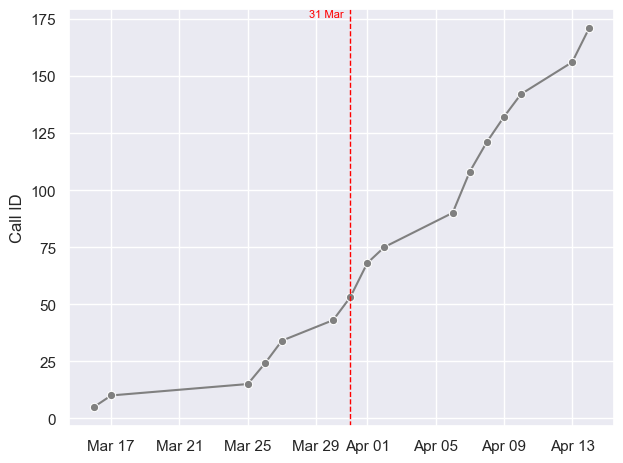

In [15]:
cum_call_id_viz = pd.DataFrame(cum_call_id.reset_index())

sns.set_theme(style='darkgrid')
ax = sns.lineplot(
    data=cum_call_id_viz,
    x='tanggal_pengerjaan',
    y='call_id',
    marker='o',
    color='grey'
)

ax.axvline(pd.to_datetime('2026-03-31'), color='red', linestyle='--', linewidth=1)
ax.text(pd.to_datetime('2026-03-31'), ax.get_ylim()[1], '31 Mar  ', 
        color='red', ha='right', va='top', fontsize=8)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.set_xlabel('')
ax.set_ylabel('Call ID')

plt.tight_layout()
plt.show()

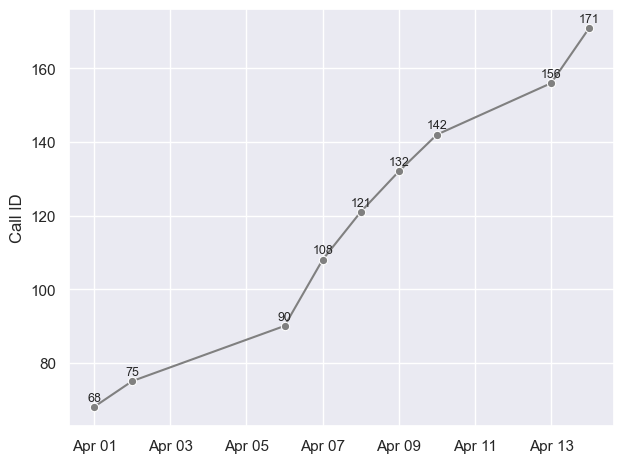

In [16]:
count_april = cum_call_id_viz[cum_call_id_viz['tanggal_pengerjaan'].dt.month == 4]
count_april = pd.DataFrame(count_april)

ax = sns.lineplot(
    data=count_april,
    x='tanggal_pengerjaan',
    y='call_id',
    marker='o',
    color='grey'
)

for x, y in zip(count_april['tanggal_pengerjaan'], count_april['call_id']):
    ax.text(x, y + 0.9, str(y), ha='center', va='bottom', fontsize=9)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.set_xlabel('')
ax.set_ylabel('Call ID')

plt.tight_layout()
plt.show()

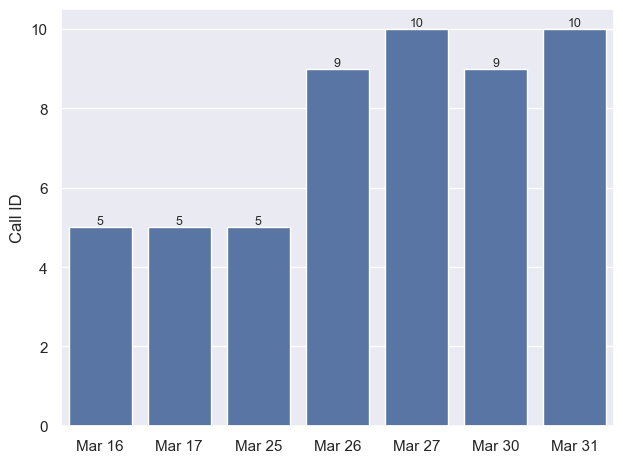

In [17]:
# hitung unique call_id per hari
daily_call_ids = (
    df_clean.groupby('tanggal_pengerjaan')['call_id']
    .nunique()
    .sort_index()
    .reset_index()
)

# filter setelah 31 Maret
daily_call_ids = daily_call_ids[daily_call_ids['tanggal_pengerjaan'] <= '2026-03-31']

# ubah tanggal menjadi label string agar barplot tidak salah membaca tanggal
daily_call_ids['tanggal_label'] = daily_call_ids['tanggal_pengerjaan'].dt.strftime('%b %d')

# plot
sns.set_theme(style='darkgrid')

ax = sns.barplot(
    data=daily_call_ids,
    x='tanggal_label',
    y='call_id',
    color='#4C72B0'
)

# label angka di atas bar
for container in ax.containers:
    ax.bar_label(container, fontsize=9)

ax.set_xlabel('')
ax.set_ylabel('Call ID')

plt.tight_layout()
plt.show()

## Prediction Model

c:\Users\ozy.prazuganda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\ozy.prazuganda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\ozy.prazuganda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\ozy.prazuganda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\ozy.prazuganda\AppData\Local\Programs\Python\Python312\

Tanggal diprediksi mencapai 300 call_id:
2026-04-26 00:00:00


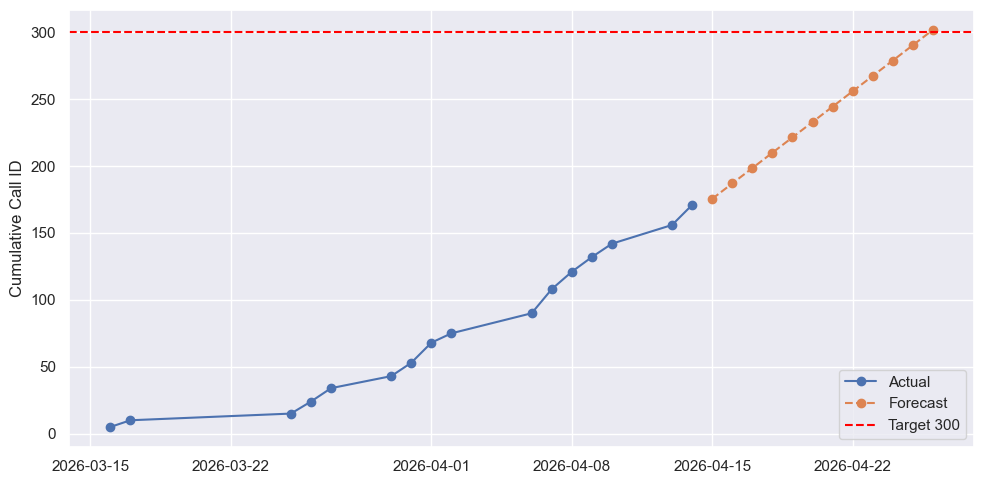

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

# =========================
# 1. Daily unique call_id
# =========================
daily_calls = (
    df_clean.groupby('tanggal_pengerjaan')['call_id']
    .nunique()
    .sort_index()
    .reset_index()
)

daily_calls['tanggal_pengerjaan'] = pd.to_datetime(daily_calls['tanggal_pengerjaan'])

# =========================
# 2. Cumulative sum
# =========================
daily_calls['cum_call_id'] = daily_calls['call_id'].cumsum()

# =========================
# 3. Feature time index
# =========================
daily_calls['t'] = np.arange(len(daily_calls))

X = daily_calls[['t']]
y = daily_calls['cum_call_id']

# =========================
# 4. Train model
# =========================
model = LinearRegression()
model.fit(X, y)

# =========================
# 5. Forecast until 300
# =========================
future_rows = []
t = daily_calls['t'].iloc[-1]

cum_pred = daily_calls['cum_call_id'].iloc[-1]
date = daily_calls['tanggal_pengerjaan'].iloc[-1]

while cum_pred < 300:
    
    t += 1
    date += pd.Timedelta(days=1)
    
    cum_pred = model.predict([[t]])[0]
    
    future_rows.append({
        'tanggal_pengerjaan': date,
        't': t,
        'cum_call_id_pred': cum_pred
    })

future_df = pd.DataFrame(future_rows)

print("Tanggal diprediksi mencapai 300 call_id:")
print(future_df[future_df['cum_call_id_pred'] >= 300].iloc[0]['tanggal_pengerjaan'])

# =========================
# 6. Plot hasil
# =========================
sns.set_theme(style='darkgrid')

plt.figure(figsize=(10,5))

plt.plot(
    daily_calls['tanggal_pengerjaan'],
    daily_calls['cum_call_id'],
    marker='o',
    label='Actual'
)

plt.plot(
    future_df['tanggal_pengerjaan'],
    future_df['cum_call_id_pred'],
    linestyle='--',
    marker='o',
    label='Forecast'
)

plt.axhline(300, color='red', linestyle='--', label='Target 300')

plt.xlabel('')
plt.ylabel('Cumulative Call ID')
plt.legend()

plt.tight_layout()
plt.show()

In [19]:

# =========================
# 1. Daily unique call_id
# =========================
daily_calls = (
    df_clean.groupby('tanggal_pengerjaan')['call_id']
    .nunique()
    .sort_index()
    .reset_index()
)

daily_calls['tanggal_pengerjaan'] = pd.to_datetime(daily_calls['tanggal_pengerjaan'])

# =========================
# 2. Buat time index
# =========================
daily_calls['t'] = np.arange(len(daily_calls))

X = daily_calls[['t']]
y = daily_calls['call_id']

# =========================
# 3. Train model
# =========================
model = LinearRegression()
model.fit(X, y)

# =========================
# 4. Prediksi 14 hari ke depan
# =========================
future_days = 14
last_t = daily_calls['t'].iloc[-1]
last_date = daily_calls['tanggal_pengerjaan'].iloc[-1]

future_data = []

for i in range(1, future_days + 1):
    
    t_future = last_t + i
    date_future = last_date + pd.Timedelta(days=i)
    
    pred = model.predict([[t_future]])[0]
    
    future_data.append({
        "tanggal_pengerjaan": date_future,
        "predicted_call_id": round(pred)
    })

future_df = pd.DataFrame(future_data)

print(future_df)

   tanggal_pengerjaan  predicted_call_id
0          2026-04-15                 16
1          2026-04-16                 16
2          2026-04-17                 17
3          2026-04-18                 18
4          2026-04-19                 18
5          2026-04-20                 19
6          2026-04-21                 19
7          2026-04-22                 20
8          2026-04-23                 21
9          2026-04-24                 21
10         2026-04-25                 22
11         2026-04-26                 23
12         2026-04-27                 23
13         2026-04-28                 24


c:\Users\ozy.prazuganda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\ozy.prazuganda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\ozy.prazuganda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\ozy.prazuganda\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\ozy.prazuganda\AppData\Local\Programs\Python\Python312\

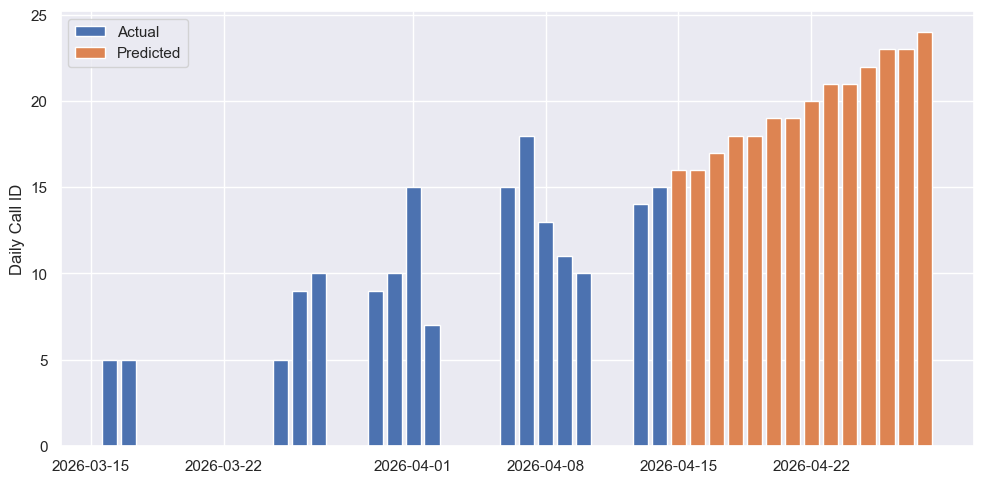

In [20]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(10,5))

plt.bar(
    daily_calls['tanggal_pengerjaan'],
    daily_calls['call_id'],
    # marker='o',
    label='Actual'
)

plt.bar(
    future_df['tanggal_pengerjaan'],
    future_df['predicted_call_id'],
    # marker='o',
    # linestyle='--',
    label='Predicted'
)

plt.xlabel('')
plt.ylabel('Daily Call ID')
plt.legend()

plt.tight_layout()
plt.show()

## 2nd Model

In [43]:
# daily unique call_id
daily_calls = (
    df_clean.groupby('tanggal_pengerjaan')['call_id']
    .nunique()
    .sort_index()
    .reset_index()
)

daily_calls['tanggal_pengerjaan'] = pd.to_datetime(daily_calls['tanggal_pengerjaan'])

# format untuk prophet
prophet_df = daily_calls.rename(columns={
    'tanggal_pengerjaan':'ds',
    'call_id':'y'
})

prophet_df.head()

,ds,y
0,2026-03-16,5
1,2026-03-17,5
2,2026-03-25,5
3,2026-03-26,9
4,2026-03-27,10


In [22]:
from prophet import Prophet

model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

model.fit(prophet_df)

13:36:46 - cmdstanpy - INFO - Chain [1] start processing
13:36:46 - cmdstanpy - INFO - Chain [1] done processing


In [23]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
41,2026-05-10,23.381470,20.457846,26.449214
42,2026-05-11,25.002955,22.198422,27.880485
43,2026-05-12,26.250009,23.498608,28.909790
44,2026-05-13,25.871411,23.048079,28.724930
45,2026-05-14,23.879774,20.642872,26.540719


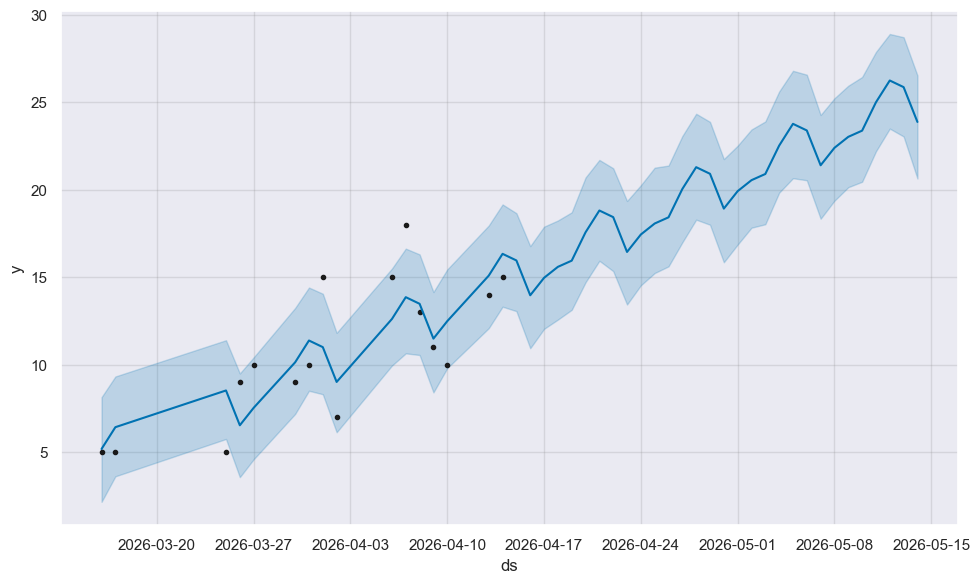

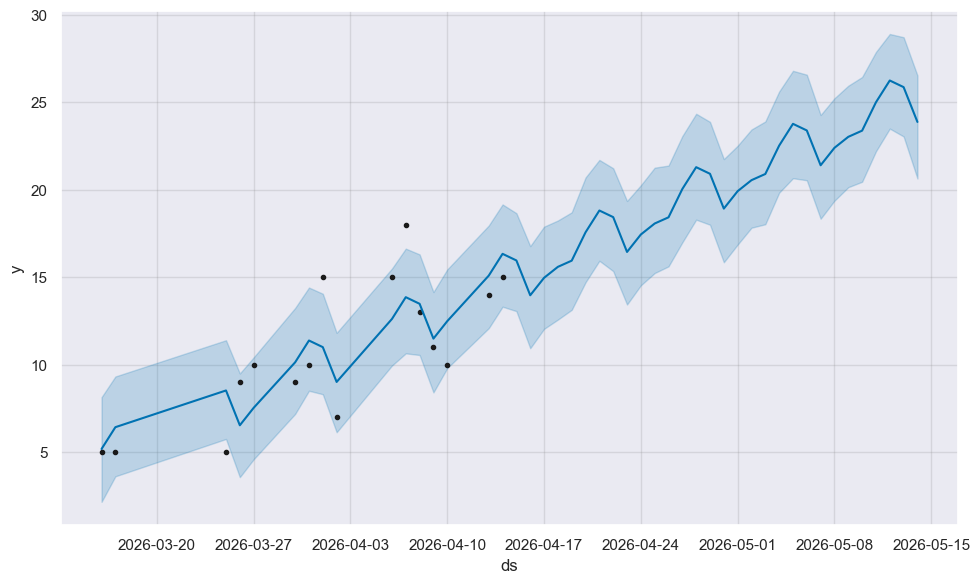

In [24]:
model.plot(forecast)

In [25]:
future_calls = forecast[['ds','yhat']].tail(30)

future_calls['yhat'] = future_calls['yhat'].round()

print(future_calls)

           ds  yhat
16 2026-04-15  16.0
17 2026-04-16  14.0
18 2026-04-17  15.0
19 2026-04-18  16.0
20 2026-04-19  16.0
21 2026-04-20  18.0
22 2026-04-21  19.0
23 2026-04-22  18.0
24 2026-04-23  16.0
25 2026-04-24  17.0
26 2026-04-25  18.0
27 2026-04-26  18.0
28 2026-04-27  20.0
29 2026-04-28  21.0
30 2026-04-29  21.0
31 2026-04-30  19.0
32 2026-05-01  20.0
33 2026-05-02  21.0
34 2026-05-03  21.0
35 2026-05-04  23.0
36 2026-05-05  24.0
37 2026-05-06  23.0
38 2026-05-07  21.0
39 2026-05-08  22.0
40 2026-05-09  23.0
41 2026-05-10  23.0
42 2026-05-11  25.0
43 2026-05-12  26.0
44 2026-05-13  26.0
45 2026-05-14  24.0


In [26]:
forecast['cum_pred'] = forecast['yhat'].cumsum()

target = forecast[forecast['cum_pred'] >= 300].iloc[0]

print("Prediksi mencapai 300 call pada:", target['ds'])

Prediksi mencapai 300 call pada: 2026-04-22 00:00:00


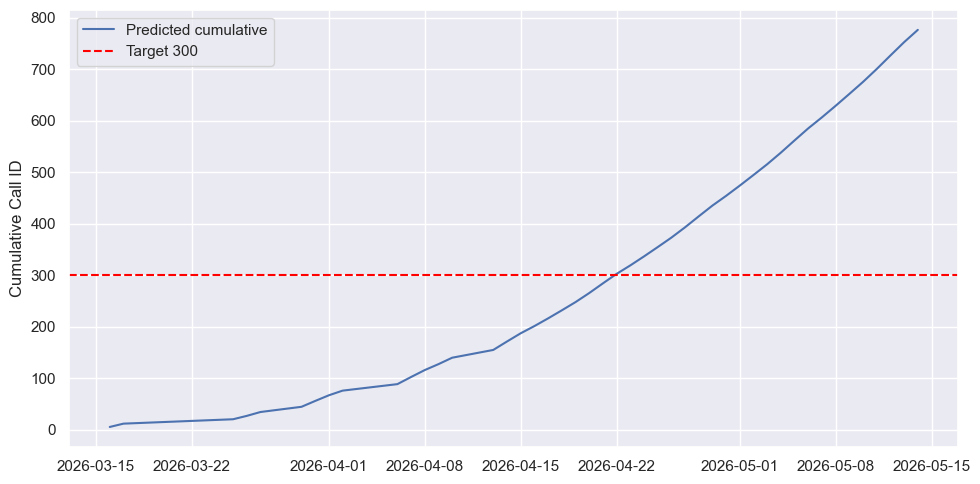

In [27]:
import matplotlib.pyplot as plt

forecast['cum_pred'] = forecast['yhat'].cumsum()

plt.figure(figsize=(10,5))

plt.plot(forecast['ds'], forecast['cum_pred'], label='Predicted cumulative')

plt.axhline(300, linestyle='--', color='red', label='Target 300')

plt.xlabel('')
plt.ylabel('Cumulative Call ID')

plt.legend()
plt.tight_layout()
plt.show()

## Prediction until 17 Apr

In [49]:
df

,No,Tanggal Pengerjaan,Checker,ASI/AFI,Waktu Inbound,Nomor Inbound,Nama Agent,Call ID,Durasi Bicara,Detik,...,Status,Sampling user side,Hasil Pemeriksaan Kualitas (old),Hasil ASR,Hasil Pemeriksaan Kualitas,Efektif,Kejelasan Suara,Suara Lain,Kelengkapan Rekaman,Agent Sampling
0,1,03/16/2026,Neneng,ASI,2026-03-15 20:00:46,0878****0038,Isnaini,a84d3724f72046409ec47e2a82cee184,0:07:58,2026-03-15 20:01:32,...,,Done,,,Percakapan Normal,Miss Target/ Not HC,"Sangat jelas, tidak bising sama sekali",0 Satu pembicara,0 Utuh,
1,2,03/16/2026,Neneng,ASI,2026-03-15 20:00:46,0878****0038,Isnaini,a84d3724f72046409ec47e2a82cee184,0:07:58,2026-03-15 20:01:40,...,,Done,,,Percakapan Normal,Miss Target/ Not HC,"Sangat jelas, tidak bising sama sekali",0 Satu pembicara,0 Utuh,
2,3,03/16/2026,Neneng,ASI,2026-03-15 20:00:46,0878****0038,Isnaini,a84d3724f72046409ec47e2a82cee184,0:07:58,2026-03-15 20:01:47,...,,Done,,,Percakapan Normal,Miss Target/ Not HC,Cukup Jelas,0 Satu pembicara,0 Utuh,
3,4,03/16/2026,Neneng,ASI,2026-03-15 20:00:46,0878****0038,Isnaini,a84d3724f72046409ec47e2a82cee184,0:07:58,2026-03-15 20:01:50,...,,Done,,,Percakapan Normal,Miss Target/ Not HC,Cukup Jelas,0 Satu pembicara,0 Utuh,
4,5,03/16/2026,Neneng,ASI,2026-03-15 20:00:46,0878****0038,Isnaini,a84d3724f72046409ec47e2a82cee184,0:07:58,2026-03-15 20:01:52,...,,Done,,,Percakapan Normal,Miss Target/ Not HC,Cukup Jelas,0 Satu pembicara,0 Utuh,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16486,16062,04/15/2026,Azer,ASI,2026-04-08 18:00:24,0859****6912,Ngamilus Solechah,68b6688f5f594163a7585ff20f681369,0:15:03,2026-04-08 18:12:45,...,,Done,,,Percakapan Normal,Miss Target/ Not HC,"Sangat jelas, tidak bising sama sekali",0 Satu pembicara,0 Utuh,
16487,16063,04/15/2026,Azer,ASI,2026-04-08 18:00:24,0859****6912,Ngamilus Solechah,68b6688f5f594163a7585ff20f681369,0:15:03,2026-04-08 18:12:51,...,,Done,,,Percakapan Normal,Miss Target/ Not HC,"Sangat jelas, tidak bising sama sekali",0 Satu pembicara,0 Utuh,
16488,16064,04/15/2026,Azer,ASI,2026-04-08 18:00:24,0859****6912,Ngamilus Solechah,68b6688f5f594163a7585ff20f681369,0:15:03,2026-04-08 18:12:58,...,,Done,,,Percakapan Normal & Aturan lainnya,Miss Target/ Not HC,Konten Non Vokal,0 Satu pembicara,1 Tidak Utuh,
16489,16065,04/15/2026,Azer,ASI,2026-04-08 18:00:24,0859****6912,Ngamilus Solechah,68b6688f5f594163a7585ff20f681369,0:15:03,2026-04-08 18:12:58,...,,Done,,,Percakapan Normal,Miss Target/ Not HC,"Sangat jelas, tidak bising sama sekali",0 Satu pembicara,0 Utuh,


In [78]:
# copy data
df_x = df.copy()

# datetime
df_x['Tanggal Pengerjaan'] = pd.to_datetime(df_x['Tanggal Pengerjaan'])

# =========================
# CREATE DAILY TARGET
# =========================
daily_target = (
    df_x.groupby('Tanggal Pengerjaan')['Call ID ']
    .nunique()
    .rename('call_id')
)

# =========================
# FEATURE ENGINEERING
# =========================

# total records per day
daily_count = df_x.groupby('Tanggal Pengerjaan').size().rename('total_rows')

# unique agents
daily_agents = df_x.groupby('Tanggal Pengerjaan')['Nama Agent'].nunique().rename('n_agents')

# unique checkers
daily_checkers = df_x.groupby('Tanggal Pengerjaan')['Checker'].nunique().rename('n_checkers')

# avg duration (convert first)
df_x['Detik '] = pd.to_numeric(df_x['Detik '], errors='coerce')

daily_duration = df_x.groupby('Tanggal Pengerjaan')['Detik '].mean().rename('avg_duration')

# risk rate
df_x['is_riskan'] = (df_x['Apakah Riskan?'] == 'Ya').astype(int)
daily_risk = df_x.groupby('Tanggal Pengerjaan')['is_riskan'].mean().rename('risk_rate')

# =========================
# MERGE ALL
# =========================
daily_df = pd.concat([
    daily_target,
    daily_count,
    daily_agents,
    daily_checkers,
    daily_duration,
    daily_risk
], axis=1)

daily_df = daily_df.sort_index()

# =========================
# TIME FEATURES
# =========================
daily_df['is_weekend'] = (daily_df.index.dayofweek >= 5).astype(int)
daily_df['day_of_week'] = daily_df.index.dayofweek
daily_df['day'] = daily_df.index.day
daily_df['month'] = daily_df.index.month

In [79]:
# lag feature
daily_df['lag_1'] = daily_df['call_id'].shift(1)
daily_df['lag_2'] = daily_df['call_id'].shift(2)
daily_df['lag_3'] = daily_df['call_id'].shift(3)

# rolling mean
daily_df['rolling_3'] = daily_df['call_id'].rolling(3).mean()

# drop NA
daily_df = daily_df.drop(columns=['avg_duration'])
daily_df = daily_df.dropna()
daily_df

,call_id,total_rows,n_agents,n_checkers,risk_rate,is_weekend,day_of_week,day,month,lag_1,lag_2,lag_3,rolling_3
Tanggal Pengerjaan,,,,,,,,,,,,,
2026-03-26,9,912,8,4,0.0,0,3,26,3,5.0,5.0,5.0,6.333333
2026-03-27,10,965,10,4,0.0,0,4,27,3,9.0,5.0,5.0,8.000000
2026-03-30,9,907,9,4,0.0,0,0,30,3,10.0,9.0,5.0,9.333333
2026-03-31,10,975,7,4,0.0,0,1,31,3,9.0,10.0,9.0,9.666667
2026-04-01,15,1254,12,4,0.0,0,2,1,4,10.0,9.0,10.0,11.333333
2026-04-02,7,963,7,3,0.0,0,3,2,4,15.0,10.0,9.0,10.666667
2026-04-06,15,1373,13,4,0.0,0,0,6,4,7.0,15.0,10.0,12.333333
2026-04-07,18,1382,14,4,0.0,0,1,7,4,15.0,7.0,15.0,13.333333
2026-04-08,13,1425,11,4,0.0,0,2,8,4,18.0,15.0,7.0,15.333333


In [85]:
# features & target
X = daily_df.drop(columns=['call_id'])
y = daily_df['call_id']

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# model
model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.5,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [86]:
pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
print('MAE: ', mae)

MAE:  2.6420505046844482


In [90]:
# predicting
future_preds = []

last_row = daily_df.iloc[-1:].copy()

for i in range(3):
    X_input = last_row.drop(columns=['call_id'])
    pred = model.predict(X_input)[0]
    next_date = last_row.index[0] + pd.Timedelta(days=1)
    new_row = last_row.copy()
    new_row.index = [next_date]

    #update lag
    new_row['lag_2'] = new_row['lag_1']
    new_row['lag_1'] = pred
    
    new_row['rolling_3'] = (new_row['lag_1'] + new_row['lag_2']) / 2
    
    # update time features
    new_row['day_of_week'] = next_date.dayofweek
    new_row['day'] = next_date.day
    new_row['month'] = next_date.month

    future_preds.append((next_date, round(pred)))

    last_row = new_row

future_preds

[(Timestamp('2026-04-16 00:00:00'), 9),
 (Timestamp('2026-04-17 00:00:00'), 9),
 (Timestamp('2026-04-18 00:00:00'), 9)]

## Comparing model

In [ ]:
# pipeline
df_clean['tanggal_pengerjaan'] = pd.to_datetime(df_clean['tanggal_pengerjaan'])

daily = (
    df_clean.groupby('tanggal_pengerjaan')['call_id']
    .nunique()
    .sort_index()
    .to_frame(name='call_id')
)

# handle missing date
daily = daily.asfreq('D')

# isi missing (lebih aman dari nol)
daily['call_id'] = daily['call_id'].interpolate()

In [94]:
# Moving Average
daily['ma_3'] = daily['call_id'].rolling(3).mean()

# drop awal NaN
ma_df = daily.dropna()

# split
split = int(len(ma_df)*0.8)

y_test = ma_df['call_id'].iloc[split:]
y_pred = ma_df['ma_3'].iloc[split:]

mae_ma = mean_absolute_error(y_test, y_pred)

print("MAE Moving Average:", mae_ma)

MAE Moving Average: 1.4444444444444446


In [ ]:
# SARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAX

split = int(len(daily)*0.8)

train = daily['call_id'].iloc[:split]
test  = daily['call_id'].iloc[split:]

model = SARIMAX(train, order=(1,1,1))
results = model.fit(disp=False)

pred = results.forecast(steps=len(test))

mae_sarima = mean_absolute_error(test, pred)

print("MAE SARIMA:", mae_sarima)

MAE SARIMA: 2.014157140269126


In [97]:
# XGBoost Regresor
# features
daily['lag_1'] = daily['call_id'].shift(1)
daily['lag_2'] = daily['call_id'].shift(2)
daily['rolling_3'] = daily['call_id'].rolling(3).mean()
daily['day_of_week'] = daily.index.dayofweek

xgb_df = daily.dropna()

X = xgb_df[['lag_1','lag_2','rolling_3','day_of_week']]
y = xgb_df['call_id']

split = int(len(X)*0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

model = XGBRegressor(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, pred)

print("MAE XGBoost:", mae_xgb)

MAE XGBoost: 1.8331808514065215


In [98]:
print("=== MODEL COMPARISON ===")
print(f"Moving Average MAE : {mae_ma:.2f}")
print(f"SARIMA MAE         : {mae_sarima:.2f}")
print(f"XGBoost MAE        : {mae_xgb:.2f}")

=== MODEL COMPARISON ===
Moving Average MAE : 1.44
SARIMA MAE         : 2.01
XGBoost MAE        : 1.83


In [106]:
pred = daily['call_id'].rolling(3).mean().iloc[-1]
pred

np.float64(13.888888888888888)

In [ ]:
daily['wma'] = (
    daily['call_id'].shift(1)*0.5 +
    daily['call_id'].shift(2)*0.3 +
    daily['call_id'].shift(3)*0.2
)

daily

,call_id,ma_3,lag_1,lag_2,rolling_3,day_of_week,wma
tanggal_pengerjaan,,,,,,,
2026-03-16,5.000000,NaN,NaN,NaN,NaN,0,NaN
2026-03-17,5.000000,NaN,5.000000,NaN,NaN,1,NaN
2026-03-18,5.000000,5.000000,5.000000,5.000000,5.000000,2,NaN
2026-03-19,5.000000,5.000000,5.000000,5.000000,5.000000,3,5.000000
2026-03-20,5.000000,5.000000,5.000000,5.000000,5.000000,4,5.000000
2026-03-21,5.000000,5.000000,5.000000,5.000000,5.000000,5,5.000000
2026-03-22,5.000000,5.000000,5.000000,5.000000,5.000000,6,5.000000
2026-03-23,5.000000,5.000000,5.000000,5.000000,5.000000,0,5.000000
2026-03-24,5.000000,5.000000,5.000000,5.000000,5.000000,1,5.000000


In [109]:
df_wma = daily.copy()

future_rows = []

for i in range(3):
    wma = (
    df_wma['call_id'].iloc[-1]*0.5 +
    df_wma['call_id'].iloc[-2]*0.3 +
    df_wma['call_id'].iloc[-3]*0.2
    )

    next_date = df_wma.index[-1] + pd.Timedelta(days=1)

    # save prediction
    new_row = pd.DataFrame({
        'call_id': [wma],
        'wma': [wma]
    }, index=[next_date])

    # append
    df_wma = pd.concat([df_wma, new_row])
    future_rows.append(new_row)

df_wma

,call_id,ma_3,lag_1,lag_2,rolling_3,day_of_week,wma
2026-03-16,5.000000,NaN,NaN,NaN,NaN,0.0,NaN
2026-03-17,5.000000,NaN,5.000000,NaN,NaN,1.0,NaN
2026-03-18,5.000000,5.000000,5.000000,5.000000,5.000000,2.0,NaN
2026-03-19,5.000000,5.000000,5.000000,5.000000,5.000000,3.0,5.000000
2026-03-20,5.000000,5.000000,5.000000,5.000000,5.000000,4.0,5.000000
2026-03-21,5.000000,5.000000,5.000000,5.000000,5.000000,5.0,5.000000
2026-03-22,5.000000,5.000000,5.000000,5.000000,5.000000,6.0,5.000000
2026-03-23,5.000000,5.000000,5.000000,5.000000,5.000000,0.0,5.000000
2026-03-24,5.000000,5.000000,5.000000,5.000000,5.000000,1.0,5.000000
2026-03-25,5.000000,5.000000,5.000000,5.000000,5.000000,2.0,5.000000
